# Domácí úkol

## Instrukce k odevzdávání
- Odevzdává se vyplněný notebook `DU4.ipynb` v repozitáři na GitHubu.
- Repozitář pro odevzdávání je `vvp-DU` a musí být veřejný na GitHubu.
- Základní část úkolu je hodnocena za 10 bodů.
- Část „Bonusové úkoly“ není součástí základního hodnocení (10 b) a je hodnocena za +2 body navíc (do maxima 50 b za domácí úkoly celkem).
- Vypracovaný úkol je potřeba pushnout do GitHubu; doporučuje se ověřit, že je pushnutý aktuální stav.
- Kontrola probíhá vždy den (nejpozději v 6:00 tam úkol musí být) před následujícím cvičením/tutoriálem; hodnotí se aktuální stav repozitáře.
- Nemažte ze souboru části se zadáním.
- Před termínem odevzdání restartujte kernel a ověřte, že je notebook plně spustitelný.
- Odevzdaný notebook nechte včetně výstupů.
- Nekopírujte řešení od kolegů; při nejasnostech se ptejte na princip, ne na hotové řešení.
- AI nástroje (Copilot, ChatGPT, Bard apod.) můžete používat, ale musíte rozumět odevzdanému řešení; slepý copy-paste bez porozumění (tedy neschopnosti odpovědět na dotaz k vašemu odevzdanému řešení) může vést k hodnocení 0 b.


## 1. Spinograf
- **Úkol: nakreslete obrázek trajektorie bodu na spinografu pro zadané hodnoty**
    - $R$ (poloměr větší kružnice),
    - $r$ (poloměr menší kružnice),
    - $d$ (vzdálenost bodu od středu menší kružnice).
- Rozmyslete si, kolik rotací musí menší kružnice udělat, aby se bod vrátil do své původní pozice (vykreslete dráhu tak, aby byla uzavřená).
- Vyzkoušejte alespoň pro $R=10, r=3, d=1$ a $R=7, r=2, d=5$.
- Vykreslete pomocí tenké modré čáry; zvolte dostatek bodů, aby byla trajektorie plynulá.

---

### Co je to spinograf?
Jedná se o hru/výukovou pomůcku (viz https://en.wikipedia.org/wiki/Spirograph).

Pro vysvětlení trajektorie bodu na spinografu (často označovaného jako hypotrochoida, když se menší kružnice otáčí uvnitř větší kružnice) použijeme goniometrický popis polohy bodu na kružnici v závislosti na úhlu rotace. Máme jednu větší kružnici s poloměrem $R$ a jednu menší kružnici s poloměrem $r$ a chceme trasovat dráhu bodu, který je od středu menší kružnice vzdálen o vzdálenost $d$.

### Poloha středu menší kružnice

Střed menší kružnice se otáčí uvnitř větší kružnice. Poloha středu menší kružnice v závislosti na úhlu $\theta$ je dána parametrickými rovnicemi v kartézských souřadnicích:

- $X = (R - r) \cos(\theta)$
- $Y = (R - r) \sin(\theta)$

kde $\theta$ je úhel rotace středu menší kružnice v radiánech.

### Otočení menší kružnice

Menší kružnice se otočí (valí se po větší kružnici). Úhel, o který se menší kružnice otočila ve svém vlastním středu vzhledem k počátečnímu bodu, je dán délkou oblouku, který urazila:
$$\theta R$$

Pokud chceme tento oblouk vyjádřit vzhledem k úhlu otočení v radiánech, o který se otočila menší kružnice ve svém středu, převádíme zpětně z obvodu na úhel:
$$\theta \frac{R}{r}$$

Poslední dvě důležitá pozorování jsou:
- malá kružnice se otočí negativně (tedy úhel je záporný),
- malá kružnice se otočí zároveň se svým středem, tedy k úhlu otočení musíme přičíst úhel $\theta$.

Celkově máme:

$$\phi = \theta - \theta \frac{R}{r} = - \theta \frac{R-r}{r}$$

### Pozice bodu na spinografu

Nakonec sloučíme pozici středu a relativní pozici bodu ve vzdálenosti $d$ od středu menší kružnice:

- $x = X + d \cos(\phi) = (R - r) \cos(\theta) + d \cos\left(- \theta \frac{R-r}{r}\right)$
- $y = Y + d \sin(\phi) = (R - r) \sin(\theta) + d \sin\left(- \theta \frac{R-r}{r}\right)$

Pokud použijeme vlastnosti (sudost/lichost) goniometrických funkcí, můžeme tyto rovnice zjednodušit na:

$$x = (R - r) \cos(\theta) + d \cos\left(\theta \frac{R-r}{r}\right)$$
$$y = (R - r) \sin(\theta) - d \sin\left(\theta \frac{R-r}{r}\right)$$

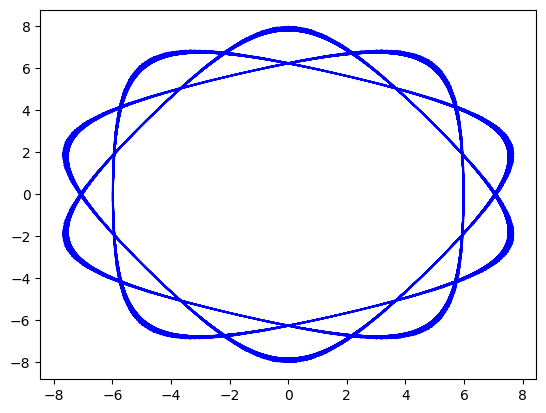

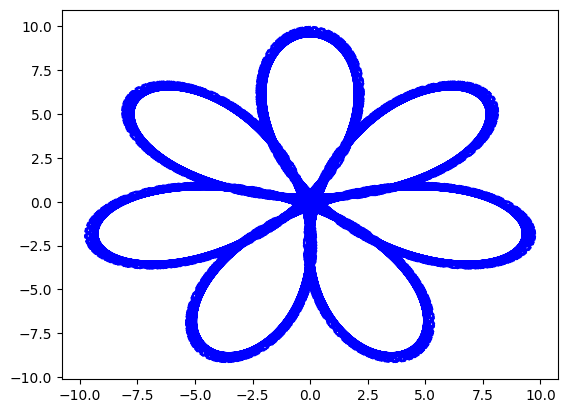

In [ ]:
import numpy as np 
import matplotlib.pyplot as plt 
 
def spingra(R , r, d ): 
    fig, axes = plt.subplots()
    i = np.linspace(0,360,1000)#libí se mi jak se graf mení podle počtu zvolených bodu že když jich mam tak cca 500 tak graf je odlišný 
    x = (R - r)*np.cos(i) + d*np.cos(i*(R-r)/r)
    y = (R - r)*np.sin(i) - d*np.sin(i*(R-r)/r)
    axes.plot(y, x , color='blue', linewidth=1) #to je nejtenčí 
    plt.show()   
        
spingra(10,3,1)
spingra(7,2,5)


## 2. Prvočíselná spirála

**Část 1: Vykreslení „slunečnicových bodů“**

- Vykreslete tzv. slunečnicové body, tedy prvních `N` takových bodů.
- Vykreslete je tak, aby byl vzor dobře vidět (zvolte vhodnou velikost bodů).

### Co jsou to slunečnicové body?
Poloměr $r$ a úhel $\theta$ pro každý bod (číslovaný přirozenými čísly: $n=1,\ldots,N$) jsou určeny následovně:

1. Zlatý úhel $\phi$ je dán vztahem:
$$
\phi = \pi \cdot (3 - \sqrt{5})
$$

2. Poloměr $r$ je odvozen z indexu bodu $n$ jako:
$$
r = \sqrt{n}
$$

3. Úhel $\theta$ pro bod $n$ je vypočítán jako:
$$
\theta = n \cdot \phi
$$

Každý bod je poté umístěn pomocí kartézských souřadnic $(x, y)$, které jsou vypočítány jako:
$$
x = r \cdot \cos(\theta)
$$
$$
y = r \cdot \sin(\theta)
$$

**Část 2: Vykreslení prvočíselné spirály**
- Vykreslete prvočíselnou spirálu pro prvních `N` prvočísel.
- Jedná se o stejný vzor jako v případě slunečnicových bodů, ale tentokrát vykreslete pouze body, které odpovídají prvočíslům.

In [ ]:
#TODO

## Bonusové úkoly
1. Modifikujte spinograf tak, aby se menší kružnice:
   - otáčela po vnější straně větší kružnice,
   - otáčela po rovnostranném $n$-úhelníku (trojúhelník, čtverec, šestiúhelník, ...).

In [ ]:
#TODO